In [17]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier

# 1. โหลดข้อมูล (ใส่ Path ของคุณ)
df = pd.read_csv('/Users/hilmanyusoh/Desktop/stock_pattern/data/ข้อมูลย้อนหลังของ ดัชนี SET 100.csv', thousands=',')

# 2. ทำความสะอาดชื่อคอลัมน์และแปลงหน่วย
df = df.rename(columns={'วันเดือนปี': 'Date', 'ล่าสุด': 'Close', 'ราคาเปิด': 'Open', 'สูงสุด': 'High', 'ต่ำสุด': 'Low', 'ปริมาณ': 'Vol_Raw'})

def convert_volume(val):
    if isinstance(val, str):
        val = val.upper()
        if 'B' in val: return float(val.replace('B', '')) * 1e9
        if 'M' in val: return float(val.replace('M', '')) * 1e6
        if 'K' in val: return float(val.replace('K', '')) * 1e3
    return float(val)

df['Volume'] = df['Vol_Raw'].apply(convert_volume)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print("--- ตรวจสอบข้อมูลหลัง Cleaning ---")
display(df.head())

--- ตรวจสอบข้อมูลหลัง Cleaning ---


,Date,Close,Open,High,Low,Vol_Raw,% เปลี่ยน,Volume
0,2011-08-16,1632.90,1656.45,1657.00,1632.90,1.90M,-0.98%,1900000.0
1,2011-08-17,1659.84,1647.02,1662.93,1645.03,2.03M,1.65%,2030000.0
2,2011-08-18,1654.86,1669.88,1676.61,1653.01,1.96M,-0.30%,1960000.0
3,2011-08-19,1621.09,1627.69,1638.60,1616.06,2.32M,-2.04%,2320000.0
4,2011-08-22,1619.72,1620.20,1621.13,1592.81,1.89M,-0.08%,1890000.0


In [18]:
# สร้างตัวแปรเชิงเทคนิค (Features)
df['Vol_MA20'] = df['Volume'].rolling(window=20).mean()
df['Rel_Vol'] = df['Volume'] / df['Vol_MA20']
df['Close_Pos'] = ((df['Close'] - df['Low']) / (df['High'] - df['Low'])).fillna(0.5)
df['Spread'] = (df['High'] - df['Low']) / df['Close']
df['Body_Size'] = (df['Close'] - df['Open']).abs() / df['Close']
df['Support_TR'] = df['Low'].rolling(window=50).min()
df['Resistance_TR'] = df['High'].rolling(window=50).max()
df['Pos_in_Range'] = (df['Close'] - df['Low'].rolling(20).min()) / (df['High'].rolling(20).max() - df['Low'].rolling(20).min())

df = df.dropna().reset_index(drop=True)

print("--- ตัวอย่าง Features ที่สร้างขึ้น ---")
display(df[['Date', 'Rel_Vol', 'Close_Pos', 'Pos_in_Range']].head())

--- ตัวอย่าง Features ที่สร้างขึ้น ---


,Date,Rel_Vol,Close_Pos,Pos_in_Range
0,2011-10-25,0.638003,0.920532,0.792144
1,2011-10-26,0.617077,0.551661,0.765534
2,2011-10-27,1.099215,0.752582,0.928316
3,2011-10-28,1.156638,0.147198,0.913070
4,2011-10-31,0.658979,0.351861,0.915162


In [19]:
def detect_wyckoff_events(df):
    df['Wyckoff_Event'] = 'Normal'
    for i in range(1, len(df)):
        # Accumulation Logic
        if df.loc[i, 'Low'] <= df.loc[i, 'Support_TR'] and df.loc[i, 'Rel_Vol'] > 1.5 and df.loc[i, 'Close_Pos'] > 0.3:
            df.loc[i, 'Wyckoff_Event'] = 'SC'
        elif df.loc[i, 'Low'] < df.loc[i-1, 'Support_TR'] and df.loc[i, 'Close'] > df.loc[i-1, 'Support_TR']:
            df.loc[i, 'Wyckoff_Event'] = 'SPRING'
        elif df.loc[i, 'Close'] > df.loc[i, 'Resistance_TR'] and df.loc[i, 'Rel_Vol'] > 1.2:
            df.loc[i, 'Wyckoff_Event'] = 'SOS'
        # Distribution Logic
        if df.loc[i, 'High'] >= df.loc[i, 'Resistance_TR'] and df.loc[i, 'Rel_Vol'] > 1.5 and df.loc[i, 'Close_Pos'] < 0.7:
            df.loc[i, 'Wyckoff_Event'] = 'BC'
        elif df.loc[i, 'High'] > df.loc[i-1, 'Resistance_TR'] and df.loc[i, 'Close'] < df.loc[i-1, 'Resistance_TR']:
            df.loc[i, 'Wyckoff_Event'] = 'UTAD'
    return df

df = detect_wyckoff_events(df)
event_names = ['Normal', 'PS', 'SC', 'AR', 'ST', 'SPRING', 'TEST', 'LPS', 'SOS', 'BU', 'PSY', 'BC', 'AR_Dist', 'UT', 'UTAD', 'SOW', 'LPSY']
event_to_idx = {name: i for i, name in enumerate(event_names)}
idx_to_event = {i: name for i, name in enumerate(event_names)}
df['Label'] = df['Wyckoff_Event'].map(event_to_idx).fillna(0).astype(int)

print("--- สรุปจำนวน Event ที่ตรวจพบ (Rule-based) ---")
print(df['Wyckoff_Event'].value_counts())

--- สรุปจำนวน Event ที่ตรวจพบ (Rule-based) ---
Wyckoff_Event
Normal    3194
UTAD       172
SPRING      81
BC          43
SC          15
Name: count, dtype: int64


In [20]:
# 1. สร้าง Lag Features ย้อนหลัง 3 วัน
base_features = ['Rel_Vol', 'Close_Pos', 'Body_Size', 'Spread', 'Pos_in_Range']
df_ml = df.copy()
for i in range(1, 4):
    for feat in base_features:
        df_ml[f'{feat}_Lag_{i}'] = df_ml[feat].shift(i)

df_ml = df_ml.dropna().reset_index(drop=True)
all_features = [col for col in df_ml.columns if any(f in col for f in base_features)]

# 2. Encoding
le = LabelEncoder()
df_ml['Encoded_Label'] = le.fit_transform(df_ml['Label'])
detected_event_names = [idx_to_event[i] for i in le.classes_]

# 3. Train Test Split & Training
X = df_ml[all_features]
y = df_ml['Encoded_Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, objective='multi:softprob', random_state=42, tree_method='hist')
model.fit(X_train, y_train)

print(f"AI ฝึกเสร็จสิ้น! รู้จักเหตุการณ์: {detected_event_names}")

AI ฝึกเสร็จสิ้น! รู้จักเหตุการณ์: ['Normal', 'SC', 'SPRING', 'BC', 'UTAD']


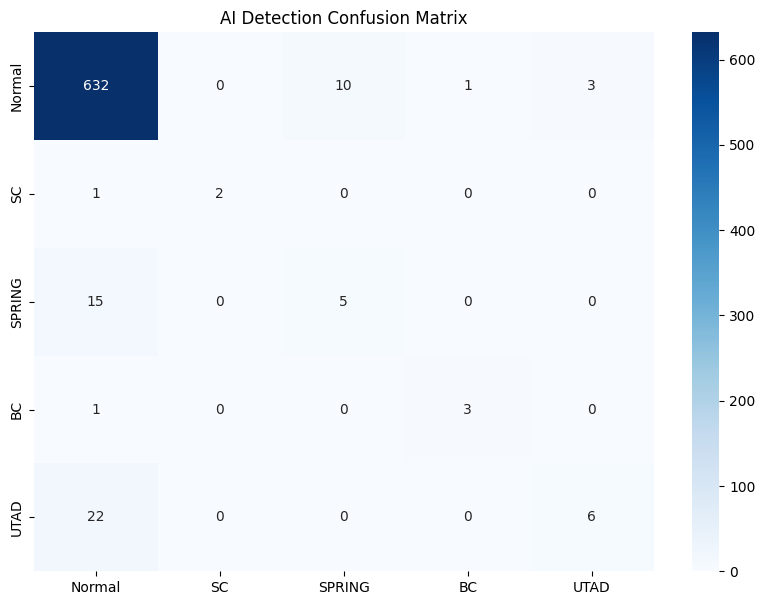

/var/folders/by/j89gc0qj6_zfzkf42sg0dr1c0000gp/T/ipykernel_22097/454450206.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




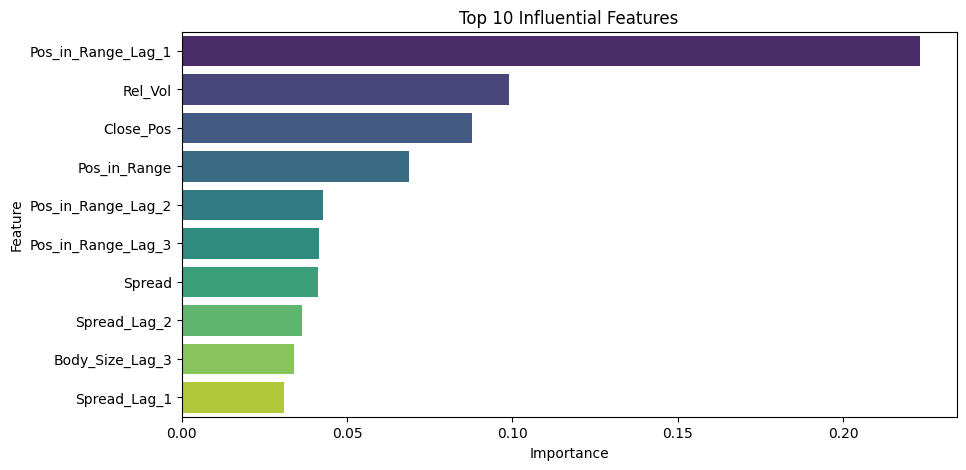

In [21]:
# 1. Confusion Matrix Heatmap
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=detected_event_names, yticklabels=detected_event_names)
plt.title('AI Detection Confusion Matrix')
plt.show()

# 2. Feature Importance
feat_imp = pd.DataFrame({'Feature': all_features, 'Importance': model.feature_importances_}).sort_values(by='Importance', ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='viridis')
plt.title('Top 10 Influential Features')
plt.show()

In [ ]:
y_probs = model.predict_proba(X_test)
test_results = df_ml.loc[X_test.index].copy()
test_results['Confidence'] = np.max(y_probs, axis=1)
test_results['Original_Idx'] = le.inverse_transform(np.argmax(y_probs, axis=1))
test_results['Event_Name'] = test_results['Original_Idx'].map(idx_to_event)

# กรองเฉพาะจุดที่มั่นใจ > 50%
detected_events = test_results[(test_results['Event_Name'] != 'Normal') & (test_results['Confidence'] > 0.5)].copy()

print(f"--- รายการที่ AI ตรวจพบ ({len(detected_events)} จุด) ---")
display(detected_events[['Date', 'Close', 'Event_Name', 'Confidence']].head(300))

--- รายการที่ AI ตรวจพบ (30 จุด) ---


,Date,Close,Event_Name,Confidence
2801,2023-04-26,2084.30,SPRING,0.879306
2804,2023-05-02,2065.32,SPRING,0.733660
2805,2023-05-03,2071.49,SPRING,0.775655
2839,2023-06-23,2037.93,SPRING,0.722855
2843,2023-06-29,2004.16,SC,0.635604
2857,2023-07-19,2097.92,UTAD,0.527820
2882,2023-08-28,2136.54,UTAD,0.553236
2909,2023-10-04,1979.07,SPRING,0.653669
2924,2023-10-27,1904.44,SPRING,0.519574
2965,2023-12-27,1934.18,UTAD,0.870805


In [23]:
fig = go.Figure(data=[go.Candlestick(x=test_results['Date'], open=test_results['Open'], high=test_results['High'], low=test_results['Low'], close=test_results['Close'], name='SET100')])

for i, row in detected_events.iterrows():
    # 1-9 = Accumulation (Green), 10-16 = Distribution (Red)
    color = "green" if 1 <= row['Original_Idx'] <= 9 else "red"
    fig.add_annotation(x=row['Date'], y=row['High'] if color == "red" else row['Low'], text=row['Event_Name'], showarrow=True, arrowhead=2, arrowcolor=color, ay=-40 if color == "red" else 40, bgcolor=color, font=dict(color="white", size=10))

fig.update_layout(title='Wyckoff AI Detection Dashboard', template='plotly_dark', xaxis_rangeslider_visible=False, height=800)
fig.show()